660710707 ณัฐกฤตา เพ็ชรคง

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
!pip install prophet

In [15]:
from prophet import Prophet

In [23]:
df = pd.read_csv("cafethai_prices.csv")
df.head()

,date,time,cash_type,coffee_name,money
0,1/3/2023,08:04:19,card,Latte,75
1,1/3/2023,08:08:54,cash,Americano with Milk,70
2,1/3/2023,08:09:03,card,Cappuccino,75
3,1/3/2023,08:10:26,cash,Cappuccino,75
4,1/3/2023,08:15:37,cash,Cappuccino,75


In [24]:
# ทำแยกตามชนิดกาแฟ

# รวม date time
df['datetime'] = pd.to_datetime(df['date'].astype(str) + " " + df['time'].astype(str), dayfirst=True)

# สร้างcolumn date เฉพาะวัน(ตัดเวลาออก)
df['date'] = df['datetime'].dt.date

# นับจำนวนแก้วที่ขายต่อวันต่อ coffee_name
daily_sales = df.groupby(['date','coffee_name']).size().reset_index(name='cups_sold')

# แสดง10อันแรก
print(daily_sales.head(10))

         date          coffee_name  cups_sold
0  2023-03-01            Americano         19
1  2023-03-01  Americano with Milk         27
2  2023-03-01           Cappuccino         24
3  2023-03-01                Cocoa          7
4  2023-03-01              Cortado         14
5  2023-03-01             Espresso          6
6  2023-03-01        Hot Chocolate          4
7  2023-03-01                Latte         24
8  2023-03-02            Americano         19
9  2023-03-02  Americano with Milk         26


DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/7xmv6kv1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/hblb6v8w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=30384', 'data', 'file=/tmp/tmp30dujylv/7xmv6kv1.json', 'init=/tmp/tmp30dujylv/hblb6v8w.json', 'output', 'file=/tmp/tmp30dujylv/prophet_modelsdazry5x/prophet_model-20250921095848.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:48 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


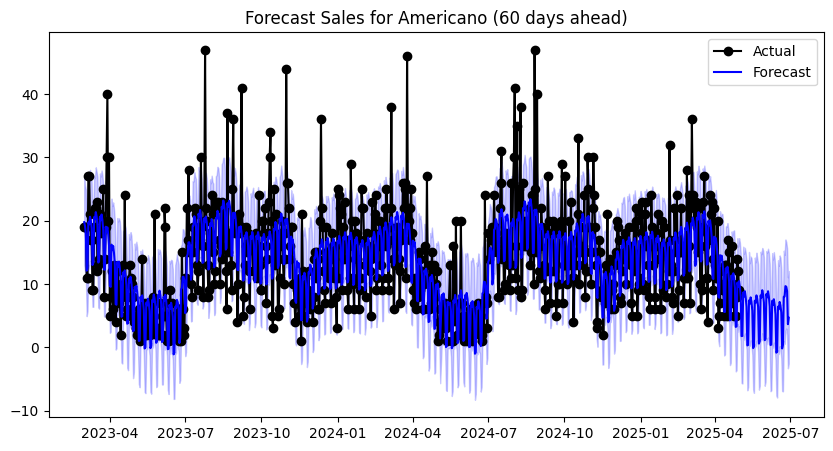

DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/r7wiaziq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/bikasfoh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48895', 'data', 'file=/tmp/tmp30dujylv/r7wiaziq.json', 'init=/tmp/tmp30dujylv/bikasfoh.json', 'output', 'file=/tmp/tmp30dujylv/prophet_model49688qda/prophet_model-20250921095848.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:48 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


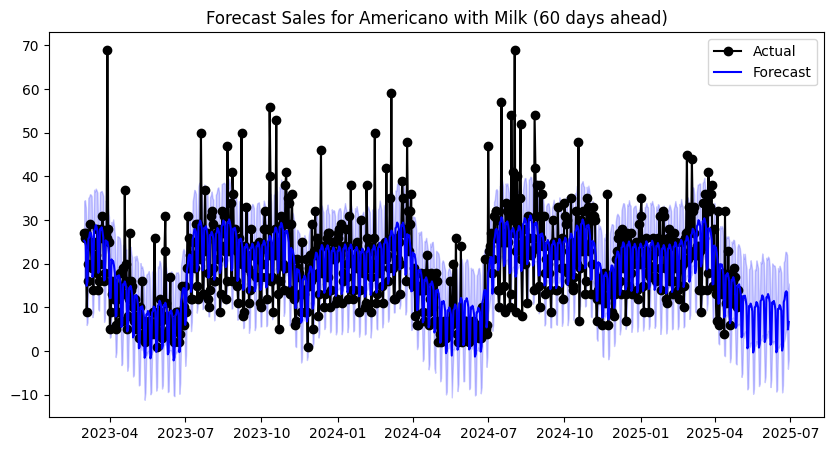

DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/fjfn8byt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/x7jqs4b3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53790', 'data', 'file=/tmp/tmp30dujylv/fjfn8byt.json', 'init=/tmp/tmp30dujylv/x7jqs4b3.json', 'output', 'file=/tmp/tmp30dujylv/prophet_modelvt5v31c7/prophet_model-20250921095849.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


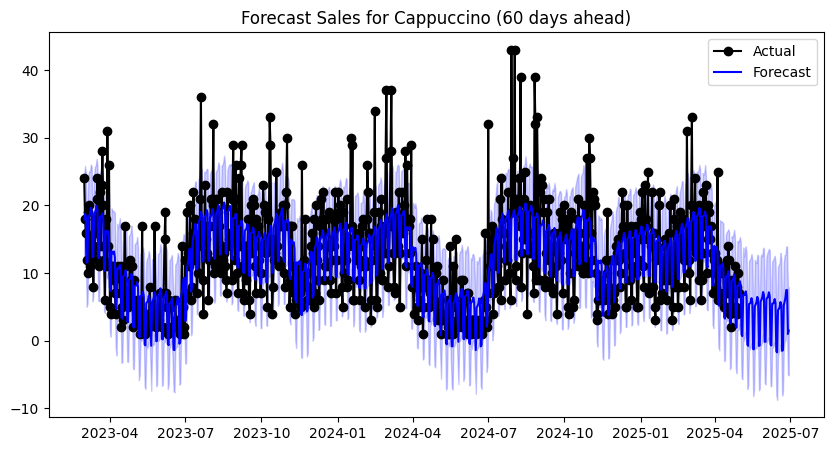

DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/8ldn4bh0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/dlj5xugu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=78929', 'data', 'file=/tmp/tmp30dujylv/8ldn4bh0.json', 'init=/tmp/tmp30dujylv/dlj5xugu.json', 'output', 'file=/tmp/tmp30dujylv/prophet_model45sg6_0q/prophet_model-20250921095849.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


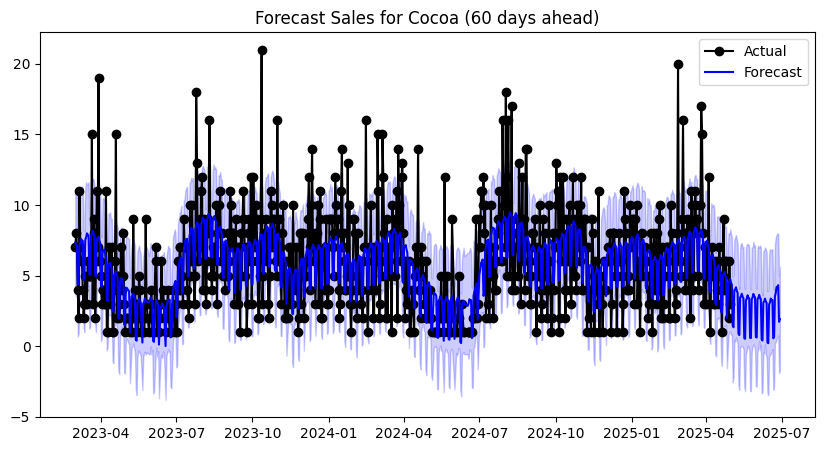

DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/ub58cpnz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/ayyoh8xn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29117', 'data', 'file=/tmp/tmp30dujylv/ub58cpnz.json', 'init=/tmp/tmp30dujylv/ayyoh8xn.json', 'output', 'file=/tmp/tmp30dujylv/prophet_modeli9060_mt/prophet_model-20250921095850.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


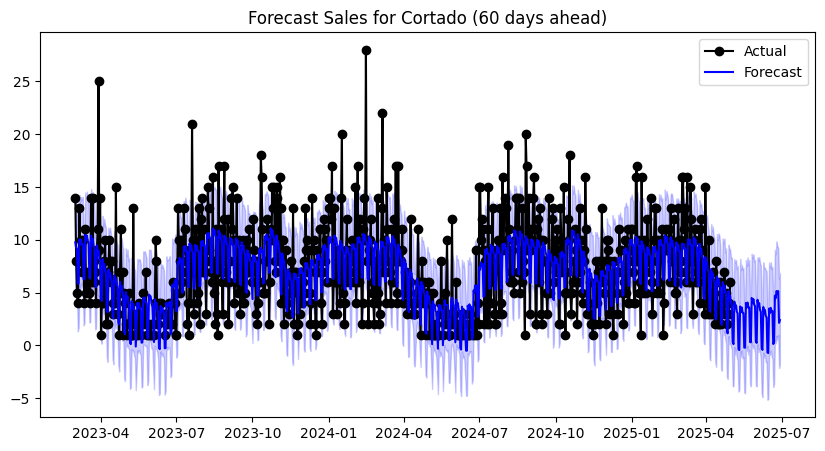

DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/tyrs846n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/c_gkjlzo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6149', 'data', 'file=/tmp/tmp30dujylv/tyrs846n.json', 'init=/tmp/tmp30dujylv/c_gkjlzo.json', 'output', 'file=/tmp/tmp30dujylv/prophet_modeldo3pgh3_/prophet_model-20250921095851.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


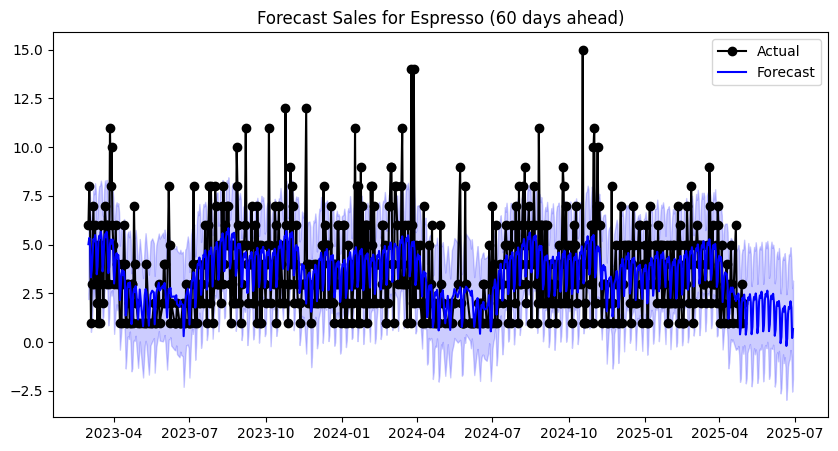

DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/0r5qpv0d.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/bpsskfym.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36680', 'data', 'file=/tmp/tmp30dujylv/0r5qpv0d.json', 'init=/tmp/tmp30dujylv/bpsskfym.json', 'output', 'file=/tmp/tmp30dujylv/prophet_modelo9wy142c/prophet_model-20250921095851.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


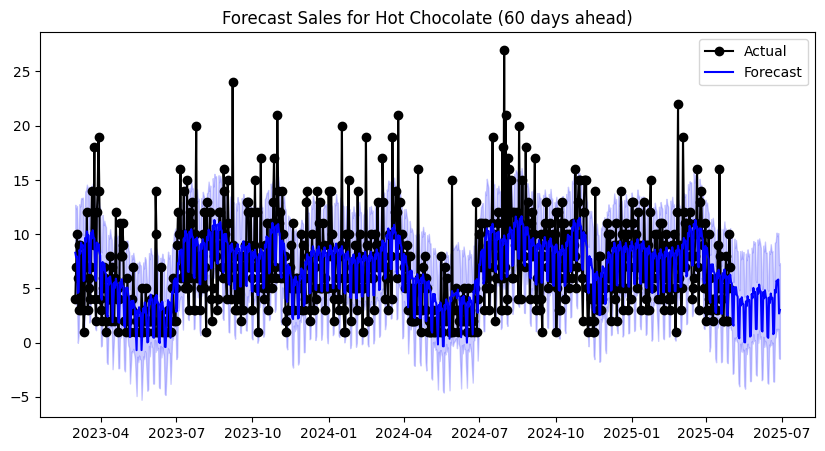

DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/qsznqhvt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp30dujylv/_ss7_634.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45419', 'data', 'file=/tmp/tmp30dujylv/qsznqhvt.json', 'init=/tmp/tmp30dujylv/_ss7_634.json', 'output', 'file=/tmp/tmp30dujylv/prophet_modelte73exh9/prophet_model-20250921095852.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:58:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:58:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


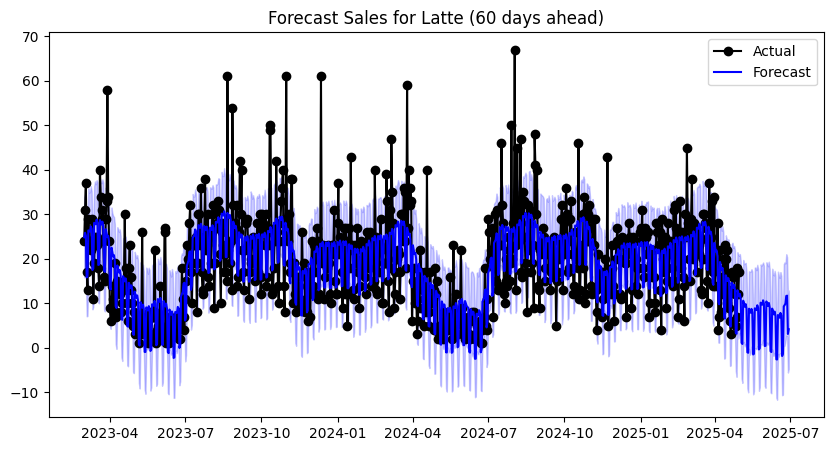

In [25]:
predictions = {}

for coffee in daily_sales['coffee_name'].unique():
    # เลือกเฉพาะกาแฟชนิดนั้น
    ts = daily_sales[daily_sales['coffee_name'] == coffee][['date','cups_sold']]

    # Prophet(ทำนายล่วงหน้า) ต้องการcolumn ds = วันที่, y = ค่าที่จะทำนาย
    ts = ts.rename(columns={'date':'ds','cups_sold':'y'})

    # สร้างและtrain model
    model = Prophet(daily_seasonality=True, yearly_seasonality=True)
    model.fit(ts)

     # ทำนาย 60 วัน
    future = model.make_future_dataframe(periods=60)

    # พยากรณ์
    forecast = model.predict(future)

    # เก็บผลลัพธ์ไว้
    predictions[coffee] = forecast

    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(ts['ds'], ts['y'], 'ko-', label='Actual')
    ax.plot(forecast['ds'], forecast['yhat'], 'b-', label='Forecast')
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='blue', alpha=0.2)
    ax.set_title(f"Forecast Sales for {coffee} (60 days ahead)")
    ax.legend()

    plt.show()


In [26]:
all_forecasts = []

for coffee, fc in predictions.items():
    # cutoff=วันล่าสุดในข้อมูลจริง
    cutoff = daily_sales['date'].max()

    # เลือกเฉพาะวันที่ > cutoff(60 วันในอนาคต)
    sub = fc[fc['ds'] > pd.to_datetime(cutoff)][['ds','yhat','yhat_lower','yhat_upper']].copy()
    sub['coffee_name'] = coffee
    all_forecasts.append(sub)

forecast_60days = pd.concat(all_forecasts)

print(forecast_60days.head())


            ds      yhat  yhat_lower  yhat_upper coffee_name
790 2025-05-01  9.506918    1.893908   16.576008   Americano
791 2025-05-02  7.936232    0.997013   14.746365   Americano
792 2025-05-03  1.759430   -5.638559    8.721948   Americano
793 2025-05-04  1.788706   -5.735361    9.186305   Americano
794 2025-05-05  8.662543    1.850740   15.892372   Americano
